# WEST boron powder drop — Afonin-style (NF 63 (2023) 126057)

150 um solid B grains (`material B`: OML heating, radiative cooling, melting
band at 2349 K, sublimation) dropped from the WEST upper shelf at the IPD
injection point (R = 2.6 m, Z = 0.75 m; wall segments 463-473 of
`wall_fine.surf`). Background: the `test_west` 1.5 MW SOLEDGE-EIRENE
plasma. Vapor spawns as kinetic B atoms and ionises to B+ (ADAS element b).
Axi convention: x = Z, y = R.

In [1]:
from __future__ import annotations
import os, shlex, subprocess, sys
from pathlib import Path
import numpy as np
import importlib
import plot_b_drop
plot_b_drop = importlib.reload(plot_b_drop)

ROOT = Path.cwd().resolve()
WEST = (ROOT / ".." / "test_west" / "input").resolve()
OPENEDGE_BIN  = Path("/Users/42d/build_oe/src/spa_mac_mpi")
OPENEDGE_ROOT = Path("/Users/42d/OpenEdge")

def run_cmd(cmd, cwd=None, env=None):
    print("+", " ".join(shlex.quote(str(p)) for p in cmd))
    subprocess.run([str(c) for c in cmd], cwd=cwd, check=True, env=env)


## 0. Sanity check: SOLEDGE background + geometry

$T_e$ on the native SOLEDGE-EIRENE triangle mesh with the wall, core-absorb
contour and the dropper segments.

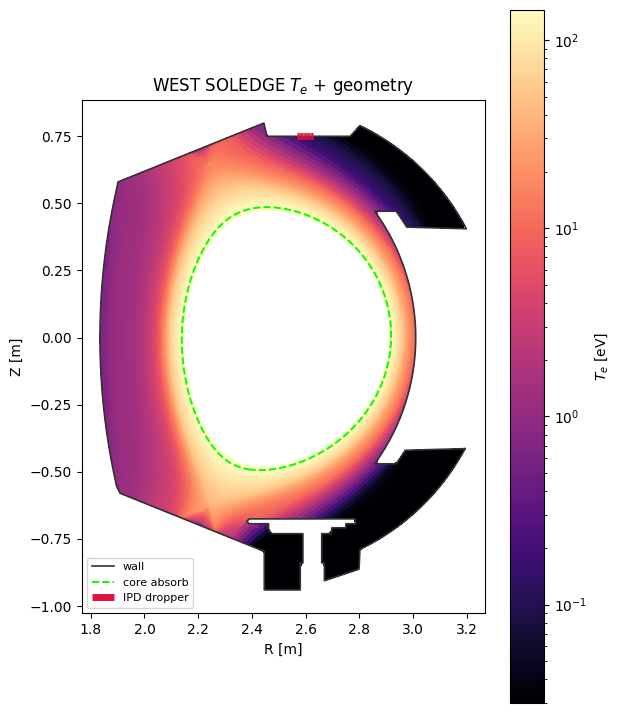

In [2]:
import h5py
import matplotlib.tri as mtri
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

%matplotlib inline

with h5py.File(WEST / "plasma.h5", "r") as f:
    vr, vz = f["mesh/vtx_r"][:], f["mesh/vtx_z"][:]
    tris, ci = f["mesh/triangles"][:], f["mesh/cell_index"][:]
    te = f["mesh/temp_e"][:]

ok = ci >= 0
W = plot_b_drop.surf_loop(WEST / "wall_fine.surf")
C = plot_b_drop.surf_loop(WEST / "core.surf")

# dropper segments 463-473 from wall_fine.surf (axi file: x=Z, y=R)
pts = {}; lines = []; mode = None
for s in (WEST / "wall_fine.surf").read_text().splitlines():
    t = s.split()
    if not t: continue
    if t[0] == "Points": mode = "p"; continue
    if t[0] == "Lines": mode = "l"; continue
    if mode == "p" and t[0].isdigit(): pts[int(t[0])] = (float(t[2]), float(t[1]))
    elif mode == "l" and len(t) == 3 and t[0].isdigit(): lines.append(tuple(map(int, t)))
drop = [[pts[a], pts[b]] for i, a, b in lines if 463 <= i <= 473]

fig, ax = plt.subplots(figsize=(6.5, 9))
tp = ax.tripcolor(mtri.Triangulation(vr, vz, tris[ok]), te[ci[ok]],
                  norm=LogNorm(), cmap="magma")
ax.plot(W[:, 0], W[:, 1], "-", color="0.2", lw=1.2, label="wall")
ax.plot(C[:, 0], C[:, 1], "--", color="lime", lw=1.4, label="core absorb")
from matplotlib.collections import LineCollection
ax.add_collection(LineCollection(drop, colors="crimson", lw=5, zorder=6,
                                 label="IPD dropper"))
ax.set_aspect("equal"); ax.set_xlabel("R [m]"); ax.set_ylabel("Z [m]")
ax.set_title("WEST SOLEDGE $T_e$ + geometry")
fig.colorbar(tp, ax=ax, label="$T_e$ [eV]")
ax.legend(loc="lower left", fontsize=8)


## 1. Deck (`in.b_west_drop`)

In [3]:
DECK = r"""# =====================================================================
# Boron powder drop into the WEST boundary plasma — Afonin-style
# (Afonin et al., Nucl. Fusion 63 (2023) 126057: IPD injection at
# R = 2.6 m, Z = 0.7 m, d = 150 um B powder falling vertically).
#
# Background: the test_west 1.5 MW SOLEDGE-EIRENE plasma.
# Grains: material B — OML heating, radiative cooling, melting band,
# sublimation; vapor spawned as kinetic B atoms, ionised to B+ (ADAS).
# Axisymmetric mode: x = Z [m], y = R [m]; B sticks where it lands
# (recycling 0 in Afonin) so all surfaces vanish-absorb.
# =====================================================================

variable    dt        equal 1.0e-6
variable    nsteps    equal 200000
variable    ndump     equal 2000
variable    nemit     equal 20000     # grain batch cadence (every 20 ms)
variable    npergroup equal 5

shell       mkdir output

seed        12345
dimension   2
boundary    o ao p
global      gridcut 0.0 comm/sort no
global      fnum 1.0e14
timestep    ${dt}

create_box  -1.00 0.85 0.0 3.25 -0.05 0.05
create_grid 200 150 1
balance_grid rcb cell
global      weight cell radius

# ---- species + mixtures ---------------------------------------------
species     bgrain_west.species bgrain
species     b.species B B+
mixture     grains bgrain frac 1.0
mixture     bvapor B frac 1.0
mixture     allB B B+

# ---- geometry (WEST wall + core absorb, axi layout) ------------------
read_surf   ../test_west_cases/axi_1p5MW_plasma_bkg/input/wall_fine.surf &
            group wall particle check
read_surf   ../test_west_cases/axi_1p5MW_plasma_bkg/input/core.surf group core

# IPD dropper = top-shelf wall segments at Z = 0.749, R 2.57-2.63
# (Afonin injection point R_inj = 2.6 m); ids from wall_fine.surf
group dropper surf id <> 463 473

surf_collide vac vanish
surf_modify  wall collide vac
surf_modify  core collide vac

# ---- WEST SOLEDGE background ----------------------------------------
fix pd background file ../test_west_cases/axi_1p5MW_plasma_bkg/input/plasma.h5 &
    static yes
global      pcache_nevery 10

# B+ pusher (axi requires mode boris)
global      pusher plasma pd mode boris &
            subcycles 10 bad_dt_check yes bad_dt_limit 0.5

# ---- grain chain: drop -> fall/drag -> charge -> ablate --------------
fix fdrop   grain/emit grains dropper nevery ${nemit} n ${npergroup} &
            perspecies no normal no vmin 0.5 vmax 1.5 angle cosine

# gravity given as physical (gR, gZ, gphi)
fix fdrag   grain/drag 1 2.0 1 background pd gravity 0 -9.8 0 &
            model epstein material B mixture grains
fix fcharge grain/charge 1 background pd ion_mass_amu 2.0 &
            thermionic yes material B mixture grains
fix fevap   grain/ablate 1 grains background pd &
            heating oml ion_mass_amu 2.0 material B emit_into bvapor
fix fchem   volume/chem/adas 1 B b.reactions output summary

# ---- diagnostics -----------------------------------------------------
# type 1 = grain, 2 = B, 3 = B+  (x = Z, y = R)
dump dpart particle all ${ndump} output/state id type x y z vx vy vz radius temp

# total-B density [m^-3], time-averaged
fix     fpw particle/weight
compute cb  grid/weighted all allB nrho_w
fix     fb  ave/grid all 100 100 10000 c_cb[1] ave one
dump    dgrid grid all 100000 output/b_dens id xc yc f_fb

stats       ${ndump}
stats_style step cpu np f_fevap
run         ${nsteps}
"""
(ROOT/"in.b_west_drop").write_text(DECK)
print("wrote in.b_west_drop")


wrote in.b_west_drop


## 2. Run (~1 min on 4 ranks)

In [4]:
env = dict(os.environ, OPENEDGE_ROOT=str(OPENEDGE_ROOT))
import shutil
mpirun = shutil.which("mpirun") or "/opt/homebrew/bin/mpirun"
run_cmd([mpirun, "-np", "4", OPENEDGE_BIN, "-in", "in.b_west_drop"], cwd=ROOT, env=env)


+ /opt/homebrew/bin/mpirun -np 4 /Users/42d/build_oe/src/spa_mac_mpi -in in.b_west_drop
SPARTA-OPENDGE (20 Jan 2025)
Running on 4 MPI task(s)
Created orthogonal box = (-1 0 -0.05) to (0.85 3.25 0.05)
Created 30000 child grid cells
  CPU time = 0.000649 secs
  create/ghost percent = 79.661 20.339
Balance grid migrated 22500 cells
  CPU time = 0.005098 secs
  reassign/sort/migrate/ghost percent = 40.7022 0.627697 28.9329 29.7372
Reading surface file ...
  808 lines
  -0.94 0.7986 xlo xhi
  1.83431 3.19847 ylo yhi
  0 0 zlo zhi
  0.0050118 min line length
  660 0 = cells overlapping surfs, overlap cells with unmarked corner pts
  8040 21300 660 = cells outside/inside/overlapping surfs
  658 2 = surf cells with 1,2,etc splits
  25.8763366762081 25.876336676208 = cell-wise and global flow volume
  CPU time = 0.00369 secs
  read/check/sort/surf2grid/ghost/inout/particle percent = 10.7317 7.31707 4.66125 49.7832 27.5068 19.5935 0
  surf2grid time = 0.001837 secs
  map/comm1/comm2/comm3/comm4/

    2000     0.062368        0            0 
    4000     0.109202        0            0 
    6000     0.165265        0            0 
    8000     0.189525        0            0 
   10000     0.212078        0            0 
   12000      0.23484        0            0 
   14000     0.257932        0            0 


   16000     0.280473        0            0 
   18000     0.303474        0            0 
   20000     0.327519        6 1.485372e-83 
   22000     0.355321        6 2.9722357e-80 
   24000     0.386593        6 5.9430362e-80 
   26000     0.418996        6 8.913906e-80 
   28000     0.450555        6 1.1884855e-79 


   30000     0.481842        6 1.4855885e-79 
   32000     0.513963        6 1.7827018e-79 
   34000     0.547189        6 2.0798281e-79 
   36000     0.579108        6 2.376968e-79 
   38000     0.611109        6 2.6741213e-79 
   40000     0.644069        8 2.9713377e-79 
   42000     0.676575        8 3.367543e-79 


   44000     0.711108        8 3.7637635e-79 
   46000     0.746615        8 4.1600011e-79 
   48000     0.782658        8 4.5562617e-79 
   50000     0.821937        8 4.9525518e-79 
   52000     0.886015        8 5.3488715e-79 


...

  192000    35.123051     2882 7.2284927e+17 


  194000    37.575725     3776 8.5113896e+17 


  196000    40.846722     4644 9.8183687e+17 


  198000    44.708381     5268 1.0959536e+18 


  200000    48.896625     5464 1.1900142e+18 
Chem/ADAS reaction tallies:
  id fchem Z=5 #-of-reactions 2
    reaction all: 13390
    ioniz: 12641
    recomb: 749
    CX: 0
    dissoc: 0
Loop time of 48.8966 on 4 procs for 200000 steps with 5464 particles

MPI task timing breakdown:
Section |  min time  |  avg time  |  max time  |%varavg| %total
---------------------------------------------------------------
Move    | 0.015443   | 9.3053     | 32.27      | 439.6 | 19.03
Coll    | 0          | 0          | 0          |   0.0 |  0.00
Sort    | 0          | 0          | 0          |   0.0 |  0.00
Comm    | 0.33044    | 0.48578    | 0.8001     |  26.5 |  0.99
Modify  | 2.107      | 5.8823     | 15.487     | 230.4 | 12.03
Output  | 0.060734   | 0.065225   | 0.067362   |   1.0 |  0.13
Pcache  | 0.000998   | 0.025212   | 0.081263   |  20.8 |  0.05
Other   |            | 33.13      |            |       | 67.76

Particle moves    = 125525520 (126M)
Cells touched     = 147538584 (148M)
Particle 

## 3. Grain trajectories colored by evaporation flux (cf. Afonin fig. 3)
and the total-B density map

wrote /Users/42d/OpenEdge/examples/test_grain_boron/b_west_drop.png | 40 grains, B=0, B+=5427


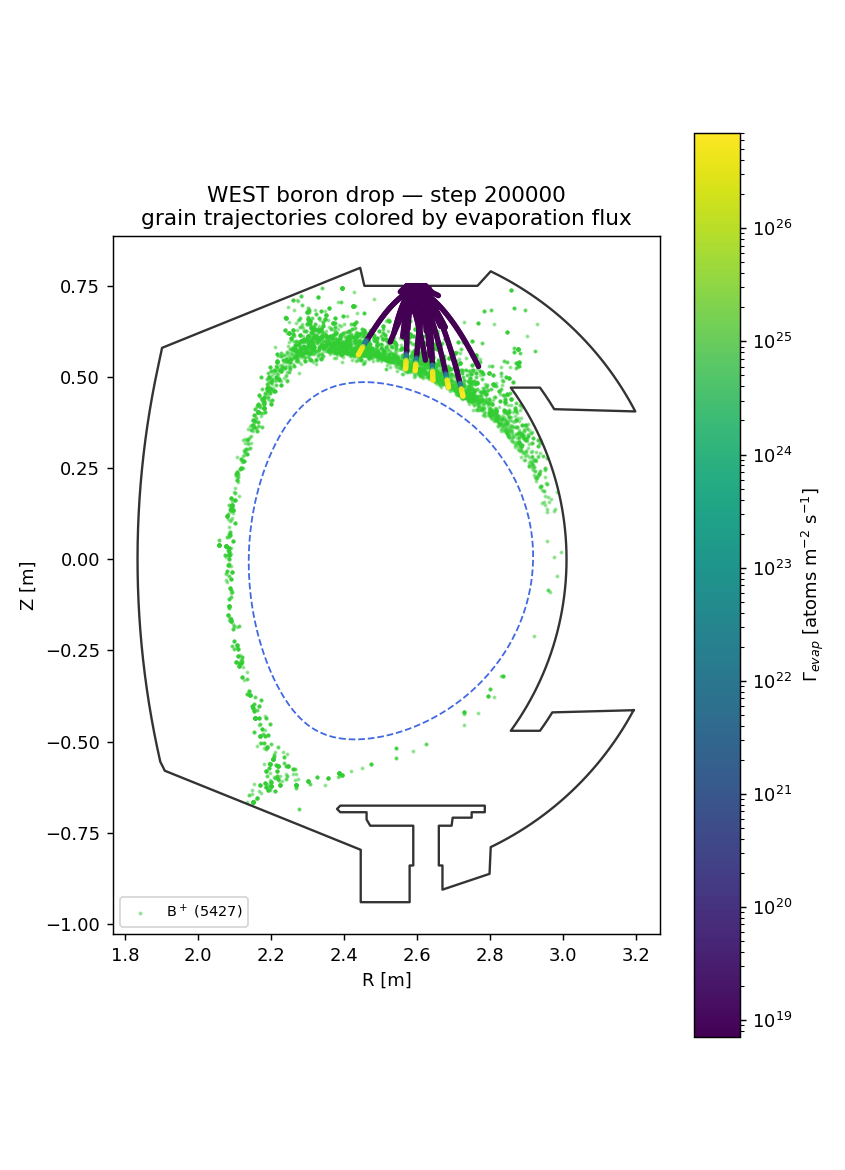

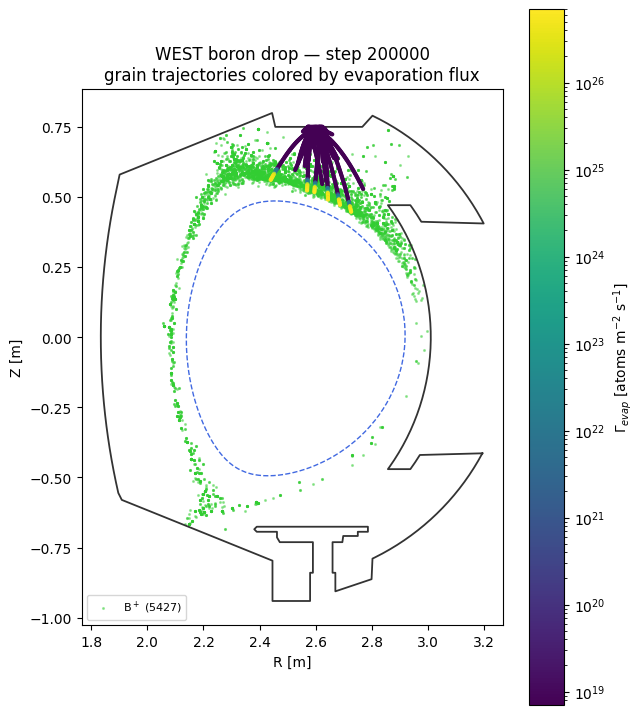

In [5]:
plot_b_drop.main()
from IPython.display import Image
Image(str(ROOT/"b_west_drop.png"))


wrote /Users/42d/OpenEdge/examples/test_grain_boron/b_west_density.png | step 200000 | n_B max = 2.664e+16 m^-3


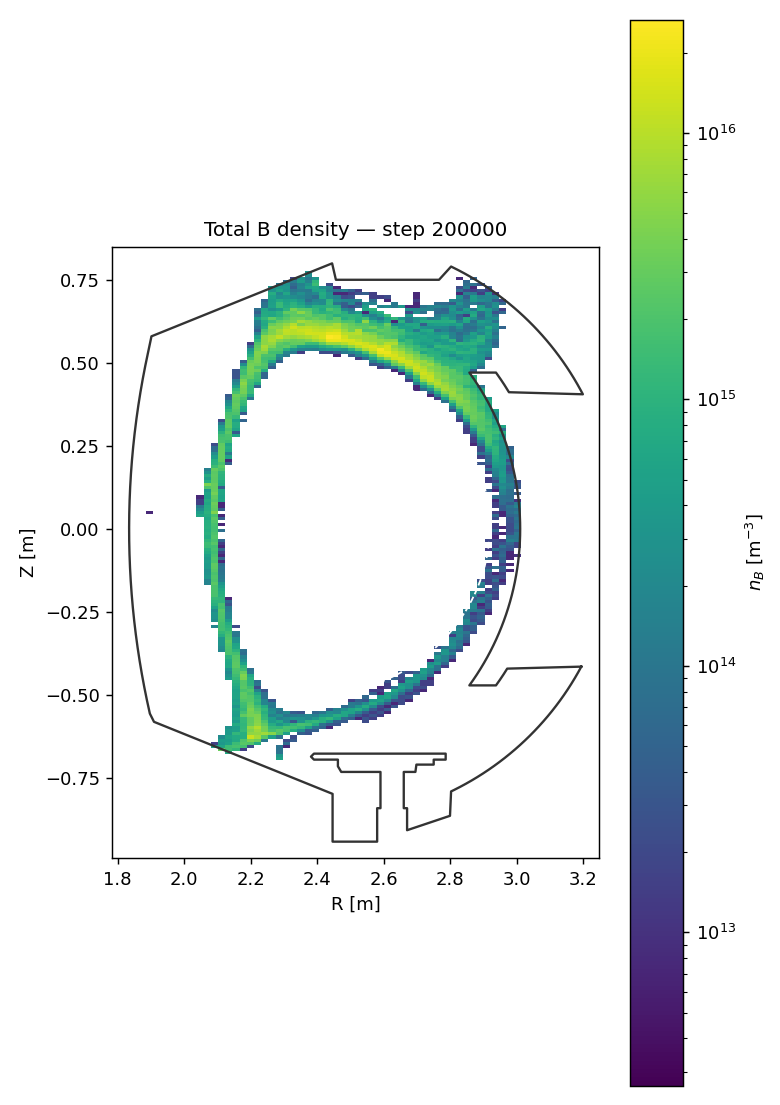

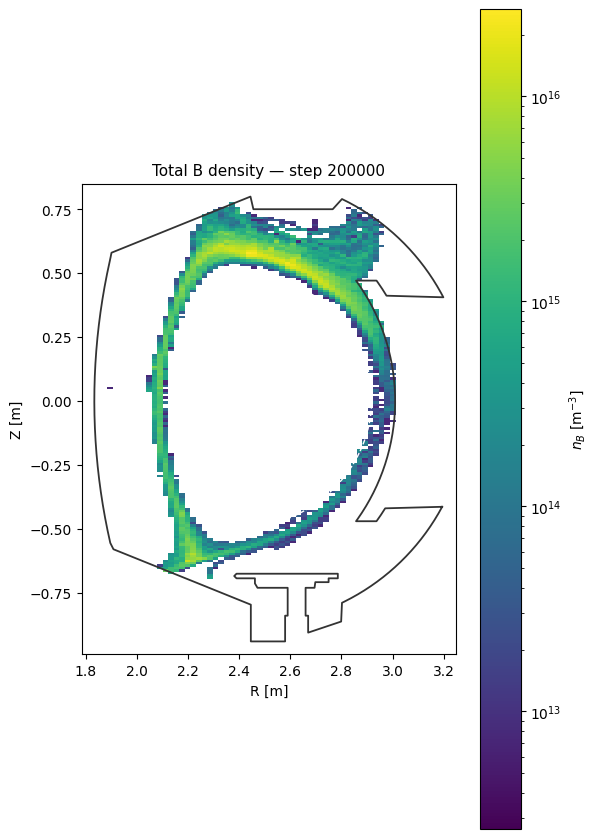

In [6]:
plot_b_drop.plot_density()
Image(str(ROOT/"b_west_density.png"))
